In [1]:
%matplotlib inline

In [3]:
# Imports
import os

SALVUS_FLOW_SITE_NAME = os.environ.get("salome_remote") # Site name given in the installation of Salvus flow
PROJECT_DIR = "simulation_wavefield_output_topo"  

# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")

import pathlib
import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 1.06 seconds]


In [20]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=60)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

In [21]:
# # Delete entire project directory to clear all cached metadata
# import shutil
# if pathlib.Path(PROJECT_DIR).exists():
#     shutil.rmtree(PROJECT_DIR)
#     print(f"Deleted {PROJECT_DIR}")

In [22]:
# Loading topography data from swisstopo, data is in a csv file 
# columns are Distance	Altitude	Easting	Northing	Longitude	Latitude
topography_data = np.genfromtxt("topo_test.csv", delimiter="\t", skip_header=1)
# Ensure 2D data and recover if parsing with tab failed
if topography_data.ndim == 1:
    topography_data = np.genfromtxt("topo_test.csv", delimiter=",", skip_header=1)

if topography_data.ndim == 1:
    topography_data = np.genfromtxt("topo_test.csv", delimiter=None, skip_header=1)

topography_data = np.atleast_2d(topography_data)
distance = topography_data[:, 0]  # Distance in km
altitude = topography_data[:, 1]  # Altitude in m

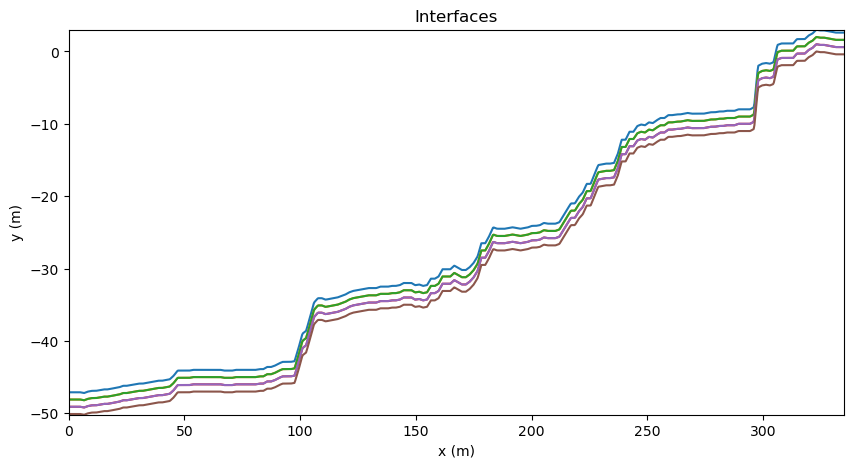

3


In [ ]:
# Layered model setup from topography profile

# Convert to float arrays
distance = np.asarray(distance, dtype=float)
altitude = np.asarray(altitude, dtype=float)

# Keep valid rows only
valid = np.isfinite(distance) & np.isfinite(altitude)
distance = distance[valid]
altitude = altitude[valid]

# Sort by distance and drop duplicate x values
order = np.argsort(distance)
distance = distance[order]
altitude = altitude[order]
distance, unique_idx = np.unique(distance, return_index=True)
altitude = altitude[unique_idx]

# If distance is in km, convert to meters (heuristic for short profiles)
if np.nanmax(distance) < 20.0:
    distance = distance * 1000.0

# Use topography as the top boundary guide
x_min = float(distance.min())
x_max = float(distance.max())

# Keep topography shape but anchor highest top boundary point at y=3 m
top_surface = altitude - np.max(altitude) + 3.0

# Other interfaces follow the same shape at 1 m and 2 m below top
interface_1m = top_surface - 1.0
interface_2m = top_surface - 2.0

# Bottom boundary for the 3rd layer (another 1 m below)
bottom_surface = top_surface - 3.0

# All interfaces use the same x-extent: distance
layers_x = [
    distance.copy(),  # top boundary
    distance.copy(),  # boundary 1 m below top
    distance.copy(),  # boundary 2 m below top
    distance.copy(),  # bottom boundary
]

layers_y = [
    top_surface,
    interface_1m,
    interface_2m,
    bottom_surface,
]

# Defining model parameters (vp, vs and rho) for earth, snow and air, earth and air velocities taken from https://pburnley.faculty.unlv.edu/GEOL452_652/seismology/notes/SeismicNotes10RVel.html
vp = np.array([2200, 300, 332])
#vs = np.array([0,0,0])
vs = np.array([880, 150,0])
rho = np.array([2000, 180, 1.2250])

interpolation_styles = ["linear"] * len(layers_x)

splines = sn.toolbox.get_interpolating_splines(
    layers_x, layers_y, kind=interpolation_styles
)

# Plotting the layer boundaries to check if they are correct
f = plt.figure(figsize=(10, 5))
x_plot = np.linspace(x_min, x_max, 1000)
for top, bot in splines:
    plt.plot(x_plot, top(x_plot))
    plt.plot(x_plot, bot(x_plot))

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Interfaces")
plt.xlim(x_min, x_max)
plt.ylim(min(bottom_surface.min(), 0.0), max(top_surface.max(), 3.0))
plt.show()

# Genetarte mesh
# Maximum frequency to resolve with elements_per_wavelength.
max_frequency = 1000

# Print lenght of splines because of size mismatch between splines and vs
shp = len(splines)
print(shp)

slowest_velocities = np.array([
    880,   # earth
    150,   # snow
    150,   # air layer meshing controlled by snow below --> need this because else slowest_velocities gives an errror because it goes to infinity
])

# Generate the mesh
mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    # make very bottom boundary, very top (in x) and both sides in y absorbing
    absorbing_boundaries=(["x0", "x1", "y0", "y1"], 10.0), # Change this if different boundaries need to be absorbing CHECK 
)

mesh = np.sum(mesh)

# Add info about absorbing boundaries CHANGE DEPENDING ON WHICH BOUNDARIES NEED TO BE TRANSPARENT / ABSORBING
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs)))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)

# Attaching parameters (vp,vs,rho) to mesh 
nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    # Find which elements are in a given region.
    idx = np.where(mesh.elemental_fields["region"] == _i)

    # Set parameters in that region to a constant value.
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

# Attach parameters.
for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

# Attach acoustic / elastic flag.
mesh_2d_layered = sn.toolbox.detect_fluid(mesh)

# # Checking which values are assigned to which layer: LAYER 0 IS THE BOTTOM LAYER
# np.unique(mesh.elemental_fields["region"])
# for i in range(3):
#     idx = mesh.elemental_fields["region"] == i
#     print(i,
#           np.unique(mesh.elemental_fields["VP"][idx]),
#           np.unique(mesh.elemental_fields["VS"][idx]),
#           np.unique(mesh.elemental_fields["RHO"][idx]))

# Plot Mesh toc heck
mesh_2d_layered
